En este cuaderno vamos a estudiar un problema mas complejo en cuanto a cantidad de datos utilizados. Se trata de el estudio de Pipeline de Procesamiento de Imágenes de Satélite para detección de Incendios. Los datos que vamos a manejar es la siguiente matirz:

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
# 48 mediciones térmicas originales (Simulación de lectura de sensor plano)
raw_satellite_data = np.array([
    120, 145, 290, 115, 130, 310, 110, 125, 285, 105, 118, 270,
    130, 150, 420, 140, 160, 450, 135, 155, 410, 125, 140, 390,
    115, 135, 260, 120, 142, 280, 122, 144, 295, 118, 138, 250,
    110, 128, 210, 112, 132, 220, 115, 134, 230, 108, 126, 205
], dtype=np.float32)

Vamos a transformar nuestra matriz en un objeto tridimensional (4,4,3) para que nos sea mas fácil gestionar y trabajar con los datos 

In [4]:
raw_satellite_data = raw_satellite_data.reshape(4, 4, 3)  # 4x4 pixeles con 3 canales rojo (R), infrarojo cercano (NIR) y infrarrojo térmico (TIR)

Ahora vamos a aislar el tercel canal en una variable llamada thermal_channel donde se nos queda una matriz 4x4

In [5]:
thermal_channel = raw_satellite_data[:, :, 2]  # Extraemos el canal térmico (TIR)
print("Canal térmico (TIR) extraído:\n", thermal_channel)

Canal térmico (TIR) extraído:
 [[290. 310. 285. 270.]
 [420. 450. 410. 390.]
 [260. 280. 295. 250.]
 [210. 220. 230. 205.]]


Ahora vamos a buscar el valor termico maxim en cada eje de latitud (fila) y en longitud (columna) el valor termico promedio.

In [6]:
maximo_fila = np.max(thermal_channel, axis=1)  # Máximo por fila (cada fila representa un pixel)
print("Máximo por fila (cada fila representa un pixel):\n", maximo_fila)
media_columna = np.mean(thermal_channel, axis=0)  # Media por columna (cada columna representa un canal)
print("Media por columna (cada columna representa un canal):\n", media_columna)

Máximo por fila (cada fila representa un pixel):
 [310. 450. 295. 230.]
Media por columna (cada columna representa un canal):
 [295.   315.   305.   278.75]


Ahora vamos a realizar un filtro para la deteccion de anomalias

In [7]:
#Calculamos la temeratura media global del canal térmico
media_global = np.mean(thermal_channel)
mascara = (thermal_channel >= 300) & (thermal_channel > media_global)  # Creamos una máscara para identificar los píxeles con temperaturas críticas
valores_criticos = thermal_channel[mascara]  # Extraemos los valores críticos
print("Valores críticos (temperaturas >= 300 y mayores que la media):\n", valores_criticos)

Valores críticos (temperaturas >= 300 y mayores que la media):
 [310. 420. 450. 410. 390.]


Por último vamos a escalar los valores para poder desplegar visualmente en un software de SIG (sistema de información geográfica)

Temperatura mínima en el canal térmico: 205.0
Temperatura máxima en el canal térmico: 450.0


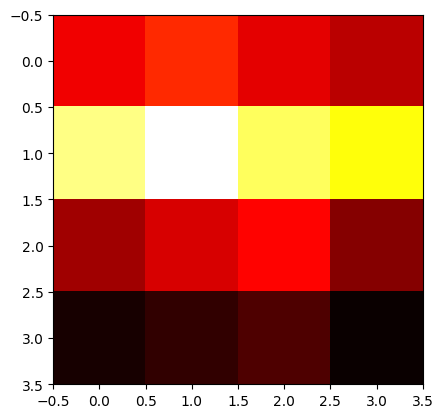

In [8]:
t_min = np.min(thermal_channel)
t_max = np.max(thermal_channel)
print(f"Temperatura mínima en el canal térmico: {t_min}")
print(f"Temperatura máxima en el canal térmico: {t_max}")
normalized_thermal = (thermal_channel - t_min) / (t_max - t_min)  # Normalizamos el canal térmico para visualización
plt.imshow(normalized_thermal, cmap='hot', interpolation='nearest')

Vamos a usar la estructura de pandas para aplicarlo a nuestro problema

In [9]:
# Datos estructurados en un diccionario de Python
data_incendios = {
    'Estacion_Monitoreo': ['Satélite-Alpha', 'Satélite-Alpha', 'Satélite-Beta', 'Satélite-Beta'],
    'Region': ['Amazonas', 'Amazonas', 'Gran Chaco', 'Gran Chaco'],
    'Temperatura_Max': [310.0, 450.0, 295.0, 230.0],  # Tus máximos por fila
    'Alerta_Incendio': [True, True, False, False]
}

# Creación del DataFrame
df_reporte = pd.DataFrame(data_incendios)

# Visualización limpia de los datos
print("Estructura del DataFrame:\n", df_reporte)

datos_incendios_altr = df_reporte[df_reporte['Alerta_Incendio'] == True]
print("Datos de incendios con alerta:\n", datos_incendios_altr)
temperatura_max = df_reporte['Temperatura_Max'].mean()
print("Temperatura máxima registrada:", temperatura_max)

Estructura del DataFrame:
   Estacion_Monitoreo      Region  Temperatura_Max  Alerta_Incendio
0     Satélite-Alpha    Amazonas            310.0             True
1     Satélite-Alpha    Amazonas            450.0             True
2      Satélite-Beta  Gran Chaco            295.0            False
3      Satélite-Beta  Gran Chaco            230.0            False
Datos de incendios con alerta:
   Estacion_Monitoreo    Region  Temperatura_Max  Alerta_Incendio
0     Satélite-Alpha  Amazonas            310.0             True
1     Satélite-Alpha  Amazonas            450.0             True
Temperatura máxima registrada: 321.25


Vamos a añadir columnas extra como lo son la diferencia entre la temperatura maxima y el promedio global y otra que nos diga q si hay alerta de incendio despliegue a los bomberos

In [11]:
#Con este codigo calculamos la diferencia entre la temperatura máxima de cada fila y la media global del canal térmico
df_reporte['Diferencia Promedio'] = df_reporte['Temperatura_Max'] - media_global
#Ahora añadimos la columna que nos avisa si hay que llamar a los bomberos o no
df_reporte['Accion_Requerida'] = np.where(df_reporte['Alerta_Incendio'],'Desplegar Bomberos','Monitoreo De Rutina')
print("DataFrame actualizado con diferencias y acciones requeridas:\n", df_reporte)

DataFrame actualizado con diferencias y acciones requeridas:
   Estacion_Monitoreo      Region  Temperatura_Max  Alerta_Incendio Planeta  \
0     Satélite-Alpha    Amazonas            310.0             True  Tierra   
1     Satélite-Alpha    Amazonas            450.0             True  Tierra   
2      Satélite-Beta  Gran Chaco            295.0            False  Tierra   
3      Satélite-Beta  Gran Chaco            230.0            False  Tierra   

   Temperatura_Kelvin  Diferencia Promedio     Accion_Requerida  
0              583.15              11.5625   Desplegar Bomberos  
1              723.15             151.5625   Desplegar Bomberos  
2              568.15              -3.4375  Monitoreo De Rutina  
3              503.15             -68.4375  Monitoreo De Rutina  


Ahora vamos a reagrupar los datos por zonas o regiones para que sea mas facil poder estudiarlos y observarlos a la hora de evitar posibles incendios

In [13]:
reporte_regiones = df_reporte.groupby('Region').agg({
    'Temperatura_Max': 'max',
    'Diferencia Promedio': 'mean'
})
print("Reporte por región:\n", reporte_regiones)

Reporte por región:
             Temperatura_Max  Diferencia Promedio
Region                                          
Amazonas              450.0              81.5625
Gran Chaco            295.0             -35.9375


Vamos a suponer que han añadido datos que son erroneos o que simplemente el sensor ha fallado o ha dejado de funcionar temporalemnte y necesitamos limpiar y depurar nuestros datos

In [14]:
# Inyectamos un fallo de lectura en la fila del Gran Chaco (Simulación de sensor apagado)
df_reporte.loc[2, 'Temperatura_Max'] = np.nan
df_reporte.loc[2, 'Diferencia Promedio'] = np.nan

print("DataFrame con fallas de transmisión:\n", df_reporte)

DataFrame con fallas de transmisión:
   Estacion_Monitoreo      Region  Temperatura_Max  Alerta_Incendio Planeta  \
0     Satélite-Alpha    Amazonas            310.0             True  Tierra   
1     Satélite-Alpha    Amazonas            450.0             True  Tierra   
2      Satélite-Beta  Gran Chaco              NaN            False  Tierra   
3      Satélite-Beta  Gran Chaco            230.0            False  Tierra   

   Temperatura_Kelvin  Diferencia Promedio     Accion_Requerida  
0              583.15              11.5625   Desplegar Bomberos  
1              723.15             151.5625   Desplegar Bomberos  
2              568.15                  NaN  Monitoreo De Rutina  
3              503.15             -68.4375  Monitoreo De Rutina  


Vamos a ver que hacemos cuando algun dato es defectuoso

In [24]:
# Identificar filas con valores faltantes
filas_faltantes = df_reporte[df_reporte['Temperatura_Max'].isna()]
print("Filas con valores faltantes:\n", filas_faltantes)

#Vamos a rellenar el valor faltante con la media de la columna 'Temperatura_Max' usando la mediana para evitar el impacto de valores atípicos
media_temperatura = df_reporte['Temperatura_Max'].median()
#Ahora vamos añadir este valor en la fila faltante
df_limpio = df_reporte[df_reporte['Temperatura_Max'].notna()]  # Copia del DataFrame sin filas con valores faltantes
# Reemplaza TODOS los NaN de la columna por su mediana de un solo golpe
mediana_temp = df_reporte['Temperatura_Max'].median()
df_reporte['Temperatura_Max'] = df_reporte['Temperatura_Max'].fillna(mediana_temp)
print("DataFrame después de limpiar los datos:\n", df_limpio)


Filas con valores faltantes:
 Empty DataFrame
Columns: [Estacion_Monitoreo, Region, Temperatura_Max, Alerta_Incendio, Planeta, Temperatura_Kelvin, Diferencia Promedio, Accion_Requerida]
Index: []
DataFrame después de limpiar los datos:
   Estacion_Monitoreo      Region  Temperatura_Max  Alerta_Incendio Planeta  \
0     Satélite-Alpha    Amazonas            310.0             True  Tierra   
1     Satélite-Alpha    Amazonas            450.0             True  Tierra   
2      Satélite-Beta  Gran Chaco            310.0            False  Tierra   
3      Satélite-Beta  Gran Chaco            230.0            False  Tierra   

   Temperatura_Kelvin  Diferencia Promedio     Accion_Requerida  
0              583.15              11.5625   Desplegar Bomberos  
1              723.15             151.5625   Desplegar Bomberos  
2              568.15              11.5625  Monitoreo De Rutina  
3              503.15             -68.4375  Monitoreo De Rutina  
